# **Imports**

In [3]:
!pip install deep-translator
!pip install nlpaug transformers
!pip install emoji
!pip install contractions
!pip install gensim
!pip install wordcloud
!pip install transformers sentencepiece accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.0 MB/s eta 0:00:00


In [4]:
# Imports
import torch.nn as nn
import pandas as pd
import numpy as np
import pandas as pd
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import re
import torch.nn.functional as F
import contractions
from torch.cuda.amp import autocast, GradScaler
import emoji
import time
from bs4 import BeautifulSoup
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import TweetTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from deep_translator import GoogleTranslator
import torch
import nlpaug.augmenter.word as naw
import nltk
from tqdm import tqdm
from transformers import pipeline
import logging
import numpy as np
import gensim.downloader as api
from nltk.corpus import stopwords
from scipy.sparse import hstack
import re
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gensim
import os
from nltk.stem import WordNetLemmatizer
from transformers import BertTokenizer
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import math
from transformers import AutoTokenizer, AutoModel, AutoConfig
import numpy as np
# Suppress warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# **Datasets**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv")
sample = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/sample_submission.csv")

# **Data Exploration**

In [ ]:
df.head()

,id,text,review
0,7961,Honestly the best part of this place is the un...,Excellent
1,4697,"Found Indulge on a whim, based on their huge ""...",Excellent
2,4459,My take on Mill street is that it's your class...,Very good
3,3714,I think Matt's has had its '5 minutes of fame'...,Bad
4,4744,Nobody likes going to the auto body shop..peri...,Excellent


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7000 non-null   int64 
 1   text    7000 non-null   object
 2   review  7000 non-null   object
dtypes: int64(1), object(2)
memory usage: 164.2+ KB


In [ ]:
df[df.duplicated()]

,id,text,review


In [ ]:
df.isnull().sum()

,0
id,0
text,0
review,0


In [ ]:
df["review"].unique()

array(['Excellent', 'Very good', 'Bad', 'Good', 'Very bad'], dtype=object)

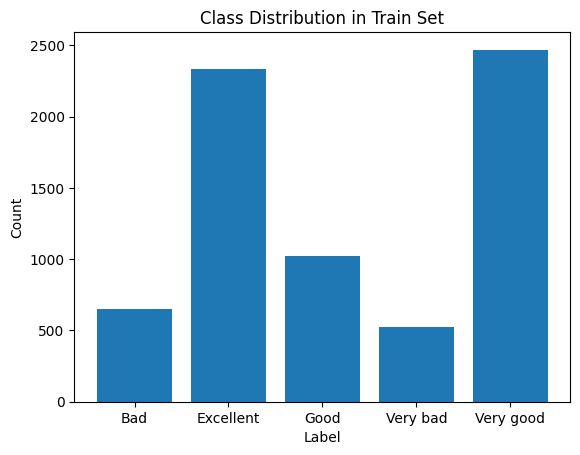

In [ ]:
train_counts = df["review"].value_counts().sort_index()

plt.figure()
plt.bar(train_counts.index, train_counts.values)
plt.title("Class Distribution in Train Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

***This indicates data bias that we need to handle.***

Generating Word Clouds...


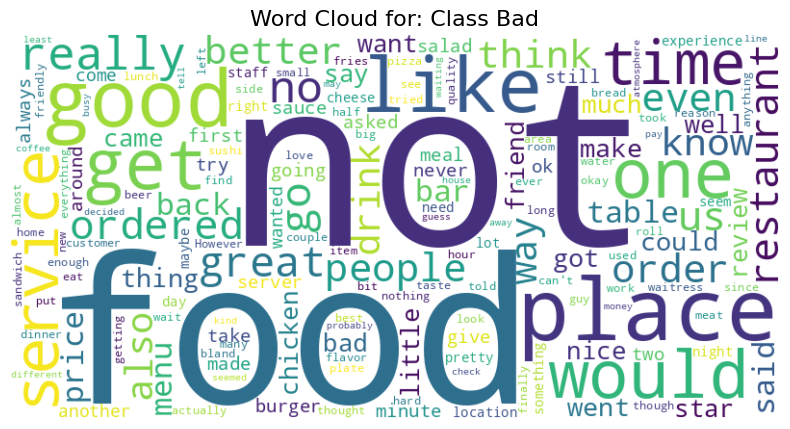

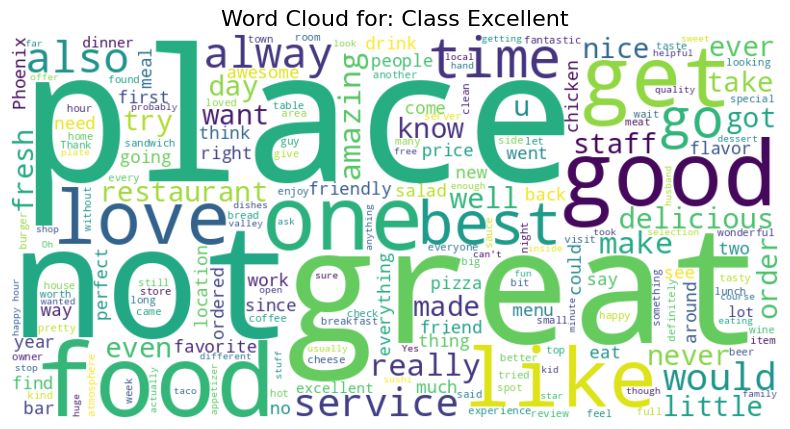

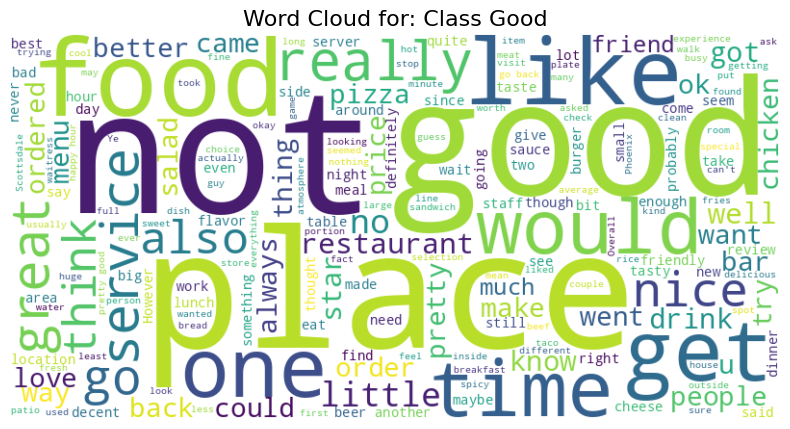

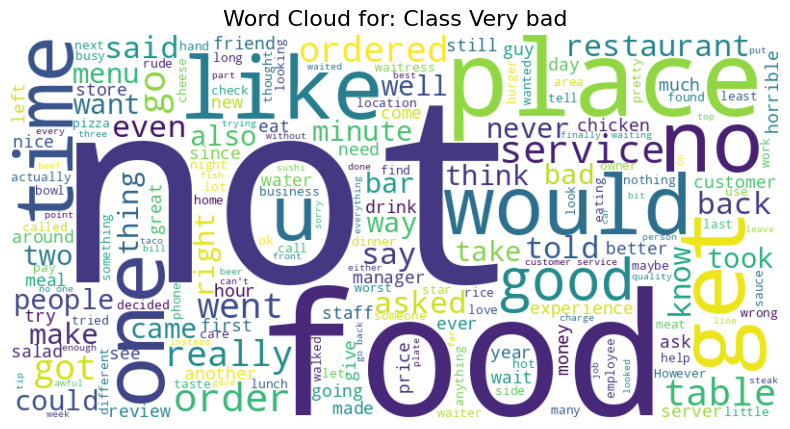

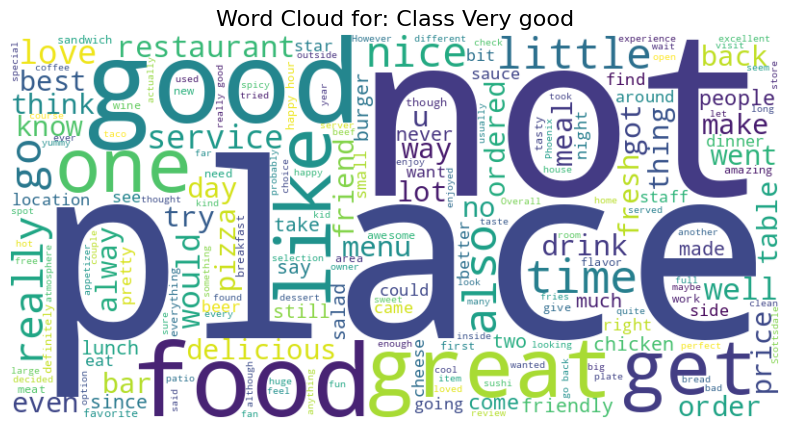

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords

id_to_label = {
    0: 'Bad',
    1: 'Excellent',
    2: 'Good',
    3: 'Very bad',
    4: 'Very good'
}

stop_words = set(stopwords.words('english'))
for word in ['not', 'no', 'nor', 'none', 'never']:
    stop_words.discard(word)

unique_labels = sorted(df['review'].unique())

for label_id in unique_labels:
    class_text = " ".join(df[df['review'] == label_id]['text'].astype(str))
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words,
        min_font_size=10
    ).generate(class_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    class_name = id_to_label.get(label_id, f"Class {label_id}")
    plt.title(f"Word Cloud for: {class_name}", fontsize=16)
    plt.show()

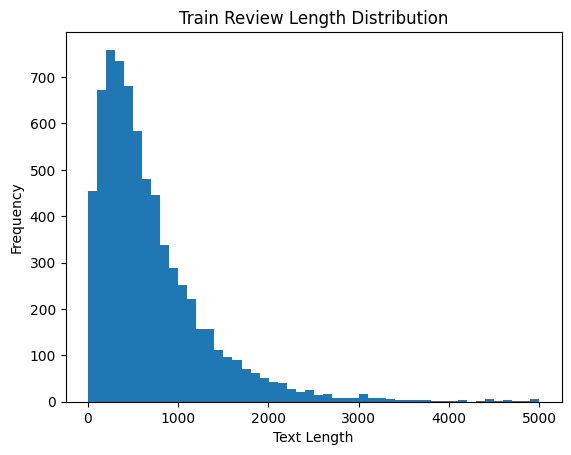

In [ ]:
train = df.copy()
train["text_length"] = df["text"].apply(len)
plt.figure()
plt.hist(train["text_length"], bins=50)
plt.title("Train Review Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

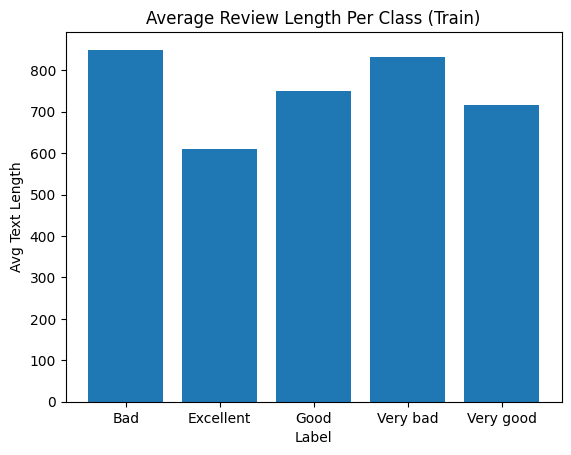

In [ ]:
avg_len = train.groupby("review")["text_length"].mean()

plt.figure()
plt.bar(avg_len.index, avg_len.values)
plt.title("Average Review Length Per Class (Train)")
plt.xlabel("Label")
plt.ylabel("Avg Text Length")
plt.show()


# **Data Preparation**

## *Train Data splitting*
*To evaluate the behaviour of the models before submission*

In [ ]:
train_df, temp_df = train_test_split(df,test_size=0.2, stratify=df['review'], random_state=42, shuffle=True)
# split the rest 20% into Validation (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['review'], random_state=42, shuffle=True)
print(f"train size: {len(train_df)}")
print(f"val size:   {len(val_df)}")
print(f"test size:  {len(test_df)}")

train size: 5600
val size:   700
test size:  700


In [ ]:
print("train class distribution:")
display(train_df['review'].value_counts(normalize=True)*100)
print("\n------------------------------------------\n")
print("validation class distribution:")
display(val_df['review'].value_counts(normalize=True)*100)
print("\n------------------------------------------\n")
print("test class distribution:")
display(test_df['review'].value_counts(normalize=True)*100)

train class distribution:


,proportion
review,
Very good,35.267857
Excellent,33.357143
Good,14.625000
Bad,9.267857
Very bad,7.482143



------------------------------------------

validation class distribution:


,proportion
review,
Very good,35.285714
Excellent,33.428571
Good,14.571429
Bad,9.142857
Very bad,7.571429



------------------------------------------

test class distribution:


,proportion
review,
Very good,35.285714
Excellent,33.285714
Good,14.714286
Bad,9.285714
Very bad,7.428571


## *Train Data Pre-processing*

### *Tools and Functions*

In [ ]:
label_encoder = LabelEncoder()
sid = SentimentIntensityAnalyzer()
tknzr = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
tokenizer = BertTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

In [ ]:
def pre_clean(text):
    text = BeautifulSoup(text, 'html.parser').get_text()

    text = re.sub(r'\[[^]]*\]', '', text)

    text = emoji.demojize(text, delimiters=(" ", " "))

    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+', '', text)

    text = " ".join(text.split())

    return text



def skip_truncation_dynamic(text, max_tokens=512, verbose=False):
    sentences = nltk.sent_tokenize(str(text))

    original_tokens = sum([len(tokenizer.tokenize(s)) for s in sentences])

    if original_tokens <= max_tokens:
        if verbose:
            print(f"PASS: Text length {original_tokens} <= {max_tokens}. No truncation needed.")
        return text

    scored_sents = []
    for i, sent in enumerate(sentences):
        score = abs(sid.polarity_scores(sent)['compound'])
        tokens = len(tokenizer.tokenize(sent))

        scored_sents.append({
            'index': i,
            'text': sent,
            'score': score,
            'len': tokens
        })

    scored_sents.sort(key=lambda x: x['score'], reverse=True)

    selected_sents = []
    current_tokens = 0

    for sent in scored_sents:
        if current_tokens + sent['len'] < (max_tokens - 2):
            selected_sents.append(sent)
            current_tokens += sent['len']
        else:
            continue

    selected_sents.sort(key=lambda x: x['index'])
    final_text = " ".join([s['text'] for s in selected_sents])

    if verbose:
        truncated_count = len(tokenizer.tokenize(final_text))
        print(f"TRUNCATED: {original_tokens} -> {truncated_count} tokens. (Dropped {original_tokens - truncated_count})")

    return final_text

### *Pre-processing*

In [ ]:
train_df = train_df.drop(columns=["id"])
train_df.columns

Index(['text', 'review'], dtype='object')

In [ ]:
train_df["label"] = label_encoder.fit_transform(train_df["review"])
train_df = train_df.drop(columns=["review"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_mapping

{'Bad': np.int64(0),
 'Excellent': np.int64(1),
 'Good': np.int64(2),
 'Very bad': np.int64(3),
 'Very good': np.int64(4)}

In [ ]:
train_df['clean_text'] = train_df['text'].apply(pre_clean)
train_df = train_df.drop(columns=["text"])

In [ ]:
# 3 (Very Bad)
# 0 (Bad)
# 2 (Good)
# 4 (Very Good)
# 1 (Excellent)
pd.set_option('display.max_colwidth', None)
display(train_df.head(20))

,label,clean_text
4424,3,"It was family day (the ex and I like to see our son smile) and we were starving... after driving around for a while we pulled up to Arriba's and said ""what the hell..."" That's also what we said when some of the food came, as in ""what the hell is this??"" So positive first. The server was pretty quick and he gave refills without being asked. Chips and salsa were good. Chips were warm and salsa had a nice (suprising) kick. Kick... do I sound like an old lady? Morgan and I ordered fish tacos and beef tacos, respectively, so we could swap one for one. Fish was ok... nothing spectacular... but honestly I would rather pay for one at freakin Del Taco or Rubios. Not worth it here. Rice was ok, some flavor, probably converted rice though. Beans were... blended? I dunno about you but I like to see some actual BEANS in my beans! This stuff was like brown goo... YUMMMMMMMM... :P The beef taco was just weird. I swear to God is tasted like gyro meat! WTF? I couldn't eat much of it. Last but not least, Dom ordered the White Sands Chimichanga. That sh*t looked nasty to be honest. Covered with some gooey white sauce, filled with pork. LOL, he said it tasted like hot dog. Um, yikes! He took about 2 bites and was ""full"". A.K.A., he didn't like it. I also had a margarita... it was HUGE and didn't taste very good. I'd rather have one 1/4 that size that tasted nice. Oh well. One star for the chips and salsa. Like I said, the fish taco was okay, but every thing was just way over-priced! Final verdict? We decided to NEVER go there again."
434,4,"My husband and I lucked into one of the best dining experiences in a long time on a recent business trip to AZ. The hummous appetizer was exceptional, as was the ""what's in this steak?"" dish, tender filet wrapped in yukon-gold potatoes (how comforting is THAT?). Nice selection of wine by the glass. The only disappointment was a dessert referred to as a ""twist on Tiramisu,"" but which bore no resemblance to it at all, with toffee cookie dough ice cream. I'll go back next time in town, but try a different dessert."
2299,4,"Love this place. Great selection of beers, cheap ($3 per beer) happy hour, relaxed atmosphere and walking distance to the Light Rail. Some nights they have live music which isn't always to my taste but I like that they provide a venue for local artists and musicians on top of everything else. On First Fridays it's packed (so good or bad depending on your feeling about crowds - I avoid it those nights) but on other nights ... it's just a very cool and comfortable place to hang out. Sometimes parking is kind of hard to find."
5868,4,"Oh Yogurtland.....why can't I resist your calling? I had to run an errand and saw this location next to a Fedex Office...perfect! I dropped in and ordered: Double Cookies & Cream, Strawberry, and Cheesecake...topped with Peanuts, Captain Crunch, and Reese's Peanut Butter Cup for around $4.90. It was of course awesome! The line was very short too....even though the weather was in the mid-90's....boy did I luck out! Return Factor - 100%"
3132,3,"Hot fudge Sunday was watered down so much. You would do much better by going to mcdonalds. This isn't the first time. I should quit giving this place chances. I'm disappointed every time. I once asked for hot fudge on the bottom of my sundae and was charged $2.60 more. The staff is rarely friendly. They should consider being friendly since it IS Dairy Queen, a place that takes many of us back to our childhoods. The array of desserts are so wonderful why not serve them wonderfully and with a smile, and not like you hate your job and just want to go home?"
1105,2,"So I was meeting some friends here last night for drinks for a friend's birthday. We were supposed to meet at 9:30 but it was around 10:30 when we actually got to the bar. We walked in and had our IDs checked and then stood around awkwardly...I'm not sure why this happened, but after a few minutes we were asked if we needed a table. Y

In [ ]:
train_df_balanced = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/train_balanced.csv")

In [ ]:
temp = train_df_balanced.copy()
temp['clean_text'] = temp['clean_text'].str.lower()
print(f"Number of duplicated rows: {temp.duplicated().sum()}")
display(temp[temp.duplicated()])

Number of duplicated rows: 2


,clean_text,label,vader_compound,bert_score
6486,this review is for the chain in general the location we went to is new so it is not in yelp yet once it is i will put this review there as well we were there on friday at pm the reason i gave it stars is because the burger was very good and it was made the way i asked for it my husbands burger was not but the server and the fries left a lot to be desired let me preface by saying that we had been to several other locations i like my fries crispy i ask for them well done extra crispy scorched tortured hollow tubes whatever their buzz word is for well done the location will comply every other guys has complied but not the one at tatum and shea she said that corporate said they are not to cook the fries that way so if we were to put up with soggy fries yes soggy then we did not want them she also interrupted us several times which is rude then she went and called corporate just to double check for us and she came to the table and said they said no they were not to cook them that way seriously we did not ask for her to do this she actually accused us of being undercover shoppers we started to say something and then again she interupted listen if you explain that our choice is not how the company wishes to present their product and we still choose to have them a different way you should comply it is after all our money and our decision i was raised with the rules that the customer is always right and if the customer is wrong refer to rule number we will not return they have lost our business and i hope she loses her job if you want to try a really good burger and fries place go to paradise valley burger company at th street and bell you will not be disappointed,0,0.8636,0.5
8801,excellent,1,0.5719,1.0


In [ ]:
temp = temp.drop_duplicates()
print(f"Number of duplicated rows: {temp.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
display(temp.head(20))

clean_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   came here for lunch recently with active yelper and friend brett b i am sure he will post up his own review of the place this is the kind of place you walk up to the register and place your order then take a plastic number to your table and the server brings you your food you also get your glass and go fill 'er up at the fountain yourself i was not sure what to expect but felt good vibes the minute i asked how big is the salad and the guy at the register walked into the kitchen to bring me a dish to show me that was nice and above my expectation as most places the servers will make a size with their hands and shrug and say i do not know about like this so yeah i like that this guy actually showed me a plate and made a mound with his hand to show me some kind of size of the salad when i ordered just water he went to give me a plastic cup with a lid and then said you know what just take a regular glass it is more comfortable he trusted me not to fill up my glass with anything but water (and i did only drink water) that was nice and made me feel like an adult not like at some places (much cheaper than this place) that give you a plastic cup like the ones you pee in at the doctor's office when you order water i really enjoyed my lunch here had a chicken caesar salad (one of my favorite things to order pretty much anywhere i go because i will never make it at home) along with a cheese pizza the caesar salad for those who have a love affair with this meal was perfect the portion was generous and it was chopped and tossed the chicken was shredded and mixed in with the salad which makes such a difference in getting an even distribution and reducing pain in the ass ness of having to cut up a chicken breast atop a salad with oversized utensils like at so many other places it was perfectly dressed too not too heavy just right and the parmesan cheese was shaved over it rather than shredded or grated nice touch excellent flavor every mouthful the cheese pizza was a cripsy ultra thin crust delicious red sauce (kind of sweet in a good way) and the cheeses were mozzarella and fontina the saltiness mixed really well with the sweetness of the sauce and made this simple pizza taste extraordinary granted having had some beyond extraordinary pizza in new york i am spoiled and have to say it was not as good as my favorite thin crust pizza from totonno's in nyc's upper east side

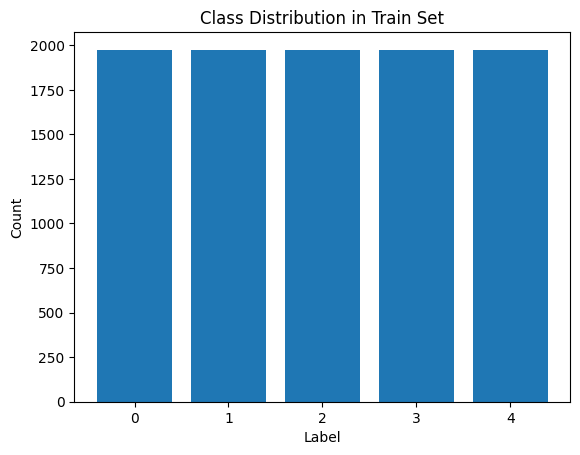

In [ ]:
train_counts = temp["label"].value_counts().sort_index()

plt.figure()
plt.bar(train_counts.index, train_counts.values)
plt.title("Class Distribution in Train Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [ ]:
# Skip truncation for transformers
transformer_train_df = temp.copy()
transformer_train_df['clean_text']= transformer_train_df['clean_text'].apply(skip_truncation_dynamic)

In [ ]:
temp.duplicated().sum()

np.int64(0)

#**Data formatting for Models training**

In [ ]:
# For tranformers
def clean_test_data_for_transformer(df, label_mapping=None):
    """
    Performs only the text cleaning and label encoding for Transformers.
    Does NOT tokenize.

    Args:
        df (pd.DataFrame): Dataframe containing 'text'.
        label_mapping (dict, optional): Dictionary to map 'review' to integers.

    Returns:
        pd.DataFrame: The dataframe with a new column 'clean_text' and encoded 'label'.
    """

    # 1. Work on a copy
    df = df.copy()

    # 2. Remove 'id' if exists
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    print("Applying light cleaning...")
    df['clean_text'] = df['text'].apply(pre_clean)
    df = df.drop(columns=['text'])
    df['clean_text']= df['clean_text'].apply(skip_truncation_dynamic)

    # 4. Handle Labels (if available)
    if 'review' in df.columns and label_mapping:
        print("Encoding labels...")
        df['label'] = df['review'].map(label_mapping)
        df = df.drop(columns=['review'])

    elif 'label' in df.columns:
        print("Labels already present.")

    return df



In [ ]:
# For transformers
transformer_train_df = transformer_train_df[['clean_text','label']]
transformer_test_df = clean_test_data_for_transformer(test_df, label_mapping=label_mapping)
# transformer_train_df = pd.concat([transformer_train_df, transformer_test_df], ignore_index=True)
transformer_val_df = clean_test_data_for_transformer(val_df, label_mapping=label_mapping)

Applying light cleaning...
Encoding labels...
Applying light cleaning...
Encoding labels...


# **Model Training**

## Encoder-only Transformer :(

### Tokenize Words

In [ ]:
# Configurations
MAX_LEN = 512
BATCH_SIZE = 8
EPOCHS = 5
LR = 5e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Extract Text and Label for Train and Validate
texts = transformer_train_df["clean_text"].tolist()
labels = torch.tensor(transformer_train_df["label"].values, dtype=torch.long)

texts_val = transformer_val_df["clean_text"].tolist()
labels_val = torch.tensor(transformer_val_df["label"].values, dtype=torch.long)

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 512
BATCH_SIZE = 8
EPOCHS = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def create_dataset(dataframe):
    if 'clean_text' not in dataframe.columns or 'label' not in dataframe.columns:
        raise ValueError("Dataframe must have 'clean_text' and 'label' columns")

    texts = dataframe['clean_text'].astype(str).tolist()
    labels = dataframe['label'].tolist()

    encodings = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )

    dataset = TensorDataset(
        encodings['input_ids'],
        encodings['attention_mask'],
        torch.tensor(labels, dtype=torch.long)
    )
    return dataset

train_dataset = create_dataset(train_df_balanced)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = create_dataset(transformer_val_df)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class DebertaCustomClassifier(nn.Module):
    def __init__(self, num_classes=5, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.hidden_size = self.bert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.hidden_size, num_classes)
        )

        self._init_weights(self.classifier)

    def _init_weights(self, module):
        for m in module:
            if isinstance(m, nn.Linear):
                torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        last_hidden_state = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        logits = self.classifier(pooled_output)
        return logits
# LLRD
def get_llrd_optimizer_params(model, encoder_lr=2e-5, decoder_lr=1e-3, weight_decay=0.01):
    no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]

    # Capture Head
    optimizer_parameters = [
        {'params': [p for n, p in model.named_parameters() if "classifier" in n],
         'lr': decoder_lr,
         'weight_decay': 0.0}
    ]

    # Capture Encoder
    layers = [model.bert.embeddings] + list(model.bert.encoder.layer)
    layers.reverse()
    lr = encoder_lr

    for layer in layers:
        optimizer_parameters.append({
            "params": [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": weight_decay, "lr": lr
        })
        optimizer_parameters.append({
            "params": [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0, "lr": lr
        })
        lr *= 0.9

    return optimizer_parameters


def train_model(model, train_loader, val_loader, epochs=5):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    params = get_llrd_optimizer_params(model, encoder_lr=2e-5, decoder_lr=1e-3)
    optimizer = optim.AdamW(params)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader))

    model.to(DEVICE)
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for input_ids, attention_mask, labels in loop:
            input_ids, attention_mask, labels = input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item() * input_ids.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")


        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for input_ids, attention_mask, labels in val_loader:
                input_ids, attention_mask, labels = input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * input_ids.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(f"\nResults Epoch {epoch+1}:")
        print(f"Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_stabilized_deberta.pt")
            print("--> Best Model Saved!")

    return model

model = DebertaCustomClassifier(num_classes=5)
train_model(model, train_loader, val_loader, epochs=EPOCHS)

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 512
BATCH_SIZE = 8

print(f"Running on: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DebertaCustomClassifier(nn.Module):
    def __init__(self, num_classes=5, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.hidden_size = self.bert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.hidden_size, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        last_hidden_state = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        logits = self.classifier(pooled_output)
        return logits

model = DebertaCustomClassifier(num_classes=5)
model.load_state_dict(torch.load("best_stabilized_deberta.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded successfully")


test_df = pd.read_csv("/content/Test cases.xlsx")

test_texts = test_df["text"].astype(str).tolist()
test_ids = test_df["id"].tolist()

encodings = tokenizer(
    test_texts,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_dataset = TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"]
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_preds = []

with torch.no_grad():
    for input_ids, attention_mask in test_loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())


id_to_label = {
    0: "Bad",
    1: "Excellent",
    2: "Good",
    3: "Very bad",
    4: "Very good"
}

pred_labels = [id_to_label[p] for p in all_preds]


output_df = pd.DataFrame({
    "id": test_ids,
    "review": pred_labels
})

output_df.to_csv("test_predictions.csv", index=False)
print("Predictions saved to test_predictions.csv")

Running on: cuda


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Model loaded successfully
Predictions saved to test_predictions.csv


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import os
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 512
BATCH_SIZE = 8
TEST_FILE_PATH = "/content/Test cases.xlsx"

print(f"Running on: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DebertaCustomClassifier(nn.Module):
    def __init__(self, num_classes=5, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.hidden_size = self.bert.config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.hidden_size, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        last_hidden_state = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        logits = self.classifier(pooled_output)
        return logits

model = DebertaCustomClassifier(num_classes=5)
if os.path.exists("best_stabilized_deberta.pt"):
    model.load_state_dict(torch.load("best_stabilized_deberta.pt", map_location=DEVICE))
    print("Model weights loaded.")
else:
    print("WARNING: 'best_stabilized_deberta.pt' not found. Running with random weights (for testing only).")

model.to(DEVICE)
model.eval()

print(f"Reading file: {TEST_FILE_PATH}")

if TEST_FILE_PATH.endswith('.xlsx'):
    test_df = pd.read_excel(TEST_FILE_PATH)
else:
    test_df = pd.read_csv(TEST_FILE_PATH)


if "text" not in test_df.columns:
    print(f"Column 'text' not found. Using the first column: {test_df.columns[0]}")
    test_texts = test_df.iloc[:, 0].astype(str).tolist()
else:
    test_texts = test_df["text"].astype(str).tolist()

encodings = tokenizer(
    test_texts,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_dataset = TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"]
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


all_preds = []
print("Starting inference...")

with torch.no_grad():
    for input_ids, attention_mask in test_loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

id_to_label = {
    0: "Bad",
    1: "Excellent",
    2: "Good",
    3: "Very bad",
    4: "Very good"
}

pred_labels = [id_to_label[p] for p in all_preds]

output_df = pd.DataFrame({
    "text": test_texts,
    "prediction": pred_labels
})

output_filename = "test_predictions.csv"
output_df.to_csv(output_filename, index=False)
print(f"Done! Predictions saved to {output_filename}")